In [1]:
print("lesson 02")

lesson 02


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
NAMES_PATH = "/Users/mikolaj/Developer/powielacz/data/names.txt"
words = open(NAMES_PATH, "r").read().splitlines()
words[:8]


['egon',
 'dymitr',
 'rudolf',
 'ingrid',
 'berta',
 'aleksander',
 'adam',
 'gerhard']

In [5]:
len(words)

600

In [13]:
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

In [69]:
# build the dataset
block_size = 3  # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "->", itos[ix])
        context = context[1:] + [ix]  # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, X.dtype, Y.shape, Y.dtype

egon
... -> e
..e -> g
.eg -> o
ego -> n
gon -> .
dymitr
... -> d
..d -> y
.dy -> m
dym -> i
ymi -> t
mit -> r
itr -> .
rudolf
... -> r
..r -> u
.ru -> d
rud -> o
udo -> l
dol -> f
olf -> .
ingrid
... -> i
..i -> n
.in -> g
ing -> r
ngr -> i
gri -> d
rid -> .
berta
... -> b
..b -> e
.be -> r
ber -> t
ert -> a
rta -> .
aleksander
... -> a
..a -> l
.al -> e
ale -> k
lek -> s
eks -> a
ksa -> n
san -> d
and -> e
nde -> r
der -> .
adam
... -> a
..a -> d
.ad -> a
ada -> m
dam -> .
gerhard
... -> g
..g -> e
.ge -> r
ger -> h
erh -> a
rha -> r
har -> d
ard -> .
balbina
... -> b
..b -> a
.ba -> l
bal -> b
alb -> i
lbi -> n
bin -> a
ina -> .
teresa
... -> t
..t -> e
.te -> r
ter -> e
ere -> s
res -> a
esa -> .
klemens
... -> k
..k -> l
.kl -> e
kle -> m
lem -> e
eme -> n
men -> s
ens -> .
fryderyk
... -> f
..f -> r
.fr -> y
fry -> d
ryd -> e
yde -> r
der -> y
ery -> k
ryk -> .
klementyna
... -> k
..k -> l
.kl -> e
kle -> m
lem -> e
eme -> n
men -> t
ent -> y
nty -> n
tyn -> a
yna -> .
lucjusz
..

(torch.Size([4704, 3]), torch.int64, torch.Size([4704]), torch.int64)

In [70]:
# C -> lookup table
C = torch.randn((31, 2))
# as my vocab size is 30 + 1

C[5]

tensor([ 1.1552, -1.1163])

In [71]:
# F.one_hot(torch.tensor(5), num_classes=31).float() @ C

In [72]:
X.shape

torch.Size([4704, 3])

In [73]:
C.shape

torch.Size([31, 2])

In [74]:
emb = C[X]
emb.shape

torch.Size([4704, 3, 2])

In [75]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [76]:
# emb @ W1 + b1 # what we want to do now
# cat
# unbind

torch.cat(torch.unbind(emb, dim=1), dim=1).shape

torch.Size([4704, 6])

In [41]:
# view
# storage
# -1 as param means "figure it out for me"
h = emb.view(emb.shape[0], -1) @ W1 + b1

In [42]:
h = torch.tanh(h) # nonlinearity // hidden layer

In [43]:
W2 = torch.randn((100, 31))
b2 = torch.randn(31)

In [44]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 31])

In [47]:
counts = logits.exp()
counts.shape

torch.Size([32, 31])

In [48]:
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([32, 31])

In [51]:
probs[0].sum() # normalized

tensor(1.0000)

In [53]:
"""
- probability treats the model as fixed and asks about
possible data
- likelihood treats the data as fixed and asks how well
different model parameters explain it

Example:

P(data | theta)

- as a probability: fix theta, vary data
- as a likelihood: fix data, vary theta

//
so for likelihoood we care aboit the 'true value' of the
  outcome?


• Yes. Exactly.

  For likelihood, you care about the probability the model
  assigned to what actually happened, not all possible outcomes.

  In your case:

  - the model outputs probabilities for all next characters
  - Y[i] tells you the true next character for example i
  - likelihood uses the probability of that true character

  So if:

  probs[i] = [0.1, 0.7, 0.2]
  Y[i] = 1

  then the relevant value is:

  probs[i, Y[i]] = 0.7

  because class 1 is the true outcome.

  That is the key intuition:

  - probability distribution = model’s opinion about every
    possible outcome
  - likelihood = how much probability the model gave to the
    outcome that really occurred

  That is why training focuses on the true target. You want the
  model to assign high probability to the real answer.

"""

likelihood = probs[torch.arange(len(Y)), Y]
loss = -likelihood.log().mean()
# negative log likelihood
loss

tensor(16.6632)

In [106]:
# now all put cleanly

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((31, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 31), generator=g)
b2 = torch.randn(31, generator=g)
parameters = [C, W1, b1, W2, b2]

In [92]:
sum(p.numel() for p in parameters)

3893

In [107]:
embd = C[X]
h = torch.tanh(embd.view(embd.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
# counts = logits.exp()
# probs = counts / counts.sum(1, keepdim=True)
# loss = -probs[torch.arange(len(Y)), Y].log().mean()
loss = F.cross_entropy(logits, Y) # same thing, more memory efficient
loss

tensor(16.1584)

In [126]:
"""cross entripy is more memory efficient,
better optimisied for forward and backward pass,
and numerically more stable"""

"28:27 pause"

lri =[]
lossi = []

for p in parameters:
    p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

for i in range(100000):
    ix = torch.randint(0, X.shape[0], (32,))
    Yb = Y[ix]

    embd = C[X[ix]]
    h = torch.tanh(embd.view(embd.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    losss = F.cross_entropy(logits, Yb)
    for p in parameters:
        p.grad = None
    losss.backward()
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lre[i].item())
    # lossi.append(losss.item())

print(losss.item())



0.9982857704162598


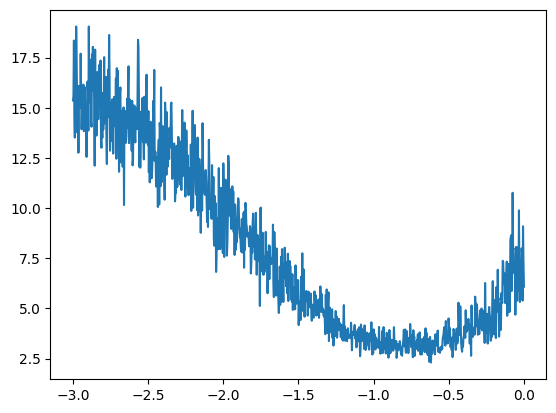

In [ ]:
# plt.plot(lri, lossi)

In [129]:
# train, dev/validation and test splits
# 80 - 10 - 10

def build_dataset(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append
    return torch.tensor(X), torch.tensor(Y)

Xtr, Ytr = build_dataset(words[:int(0.8*len(words))], block_size)
Xdev, Ydev = build_dataset(words[int(0.8*len(words)):int(0.9*len(words))], block_size)
Xte, Yte = build_dataset(words[int(0.9*len(words)):], block_size)

Ytr.shape, Ydev.shape, Yte.shape

(torch.Size([3742]), torch.Size([488]), torch.Size([474]))

In [181]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((31, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 31), generator=g)
b2 = torch.randn(31, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

stepi = []
lossi = []
sum(p.numel() for p in parameters)


12741

1.0422519445419312


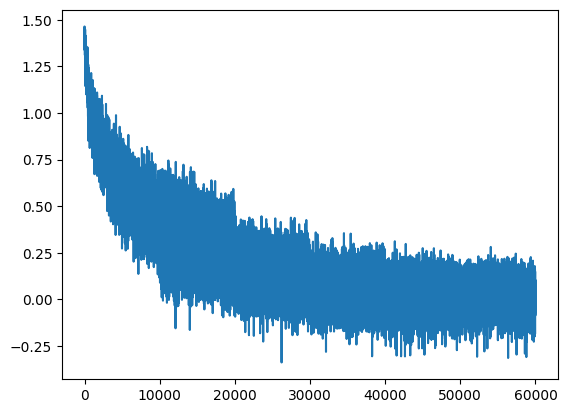

In [186]:
for i in range(10000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Yb = Ytr[ix]

    embd = C[Xtr[ix]]
    h = torch.tanh(embd.view(embd.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    losss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    losss.backward()
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(len(stepi) + i)
    lossi.append(losss.log10().item())

print(losss.item())
plt.plot(stepi, lossi)

In [187]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item()) # train loss

1.0814862251281738


In [190]:
embd = C[Xdev]
h = torch.tanh(embd.view(embd.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item()) # dev loss

3.8296236991882324


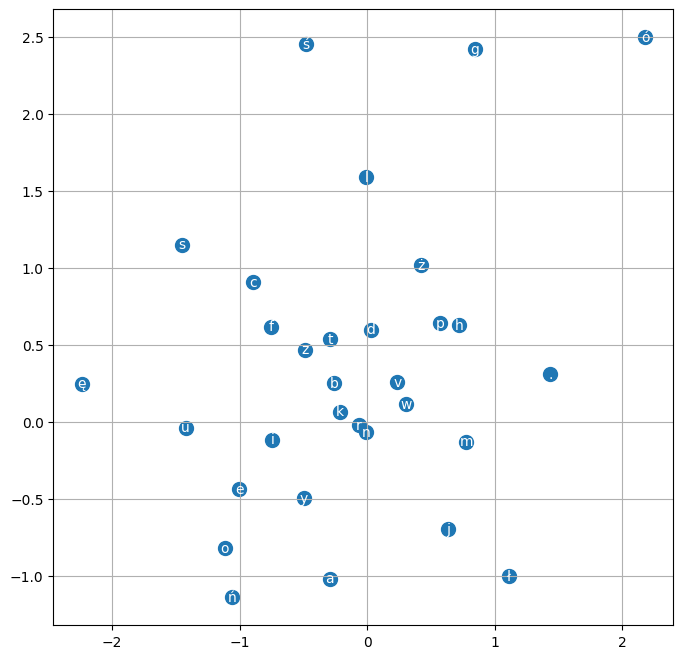

In [174]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=100)
for i in range(31):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid()

In [ ]:
"""
read the paper (19 pages?)
"""

In [192]:
# sample

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print("".join(itos[i] for i in out))

robernard.
lrosławoj.
wita.
eufenwktryacieolima.
jarosław.
dionifacy.
kyrsżgna.
toma.
zuza.
kunela.
wiols.
bogdaleria.
karołhlasta.
wena.
grzej.
irmgard.
zdy.
dionarda.
sylwebastan.
radela.
